In [1]:
import wandb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
api = wandb.Api()

In [92]:
run_baseline = api.run("viatage/DAPO-PPO/3d81b1b2-8d32-4ba5-85eb-516f400f65ab")
run_gs = api.run("viatage/DAPO-PPO/d3b18852-fcba-4ddc-9ccd-8490043270a0")
run_gs_2 = api.run("viatage/DAPO-PPO/aceff39d-579d-4771-af94-9de8ca4632c3")
run_pr = api.run("viatage/DAPO-PPO/68877010-175b-498c-bcc4-c3e42cee060e")
run_pr_2 = api.run("viatage/DAPO-PPO/1ffa5211-51dd-4694-b1eb-47d906dbfed4")
history_baseline = run_baseline.history()
history_gs = run_gs.history()
history_gs_2 = run_gs_2.history()
history_pr = run_pr.history()
history_pr_2 = run_pr_2.history()


gs_low_steps = history_gs[history_gs['_step'] <= 550].copy()
gs_high_steps = history_gs_2[history_gs_2['_step'] > 555].copy()
history_gs_combined = pd.concat([gs_low_steps, gs_high_steps], ignore_index=True)
history_gs = history_gs_combined.sort_values('_step').reset_index(drop=True)



# Filter pr data for steps <= 650
pr_low_steps = history_pr[history_pr['_step'] <= 650].copy()
# Filter pr_2 data for steps > 650  
pr_high_steps = history_pr_2[history_pr_2['_step'] > 650].copy()
# Concatenate the filtered data
history_pr_combined = pd.concat([pr_low_steps, pr_high_steps], ignore_index=True)
# Sort by _step to ensure proper ordering
history_pr = history_pr_combined.sort_values('_step').reset_index(drop=True)



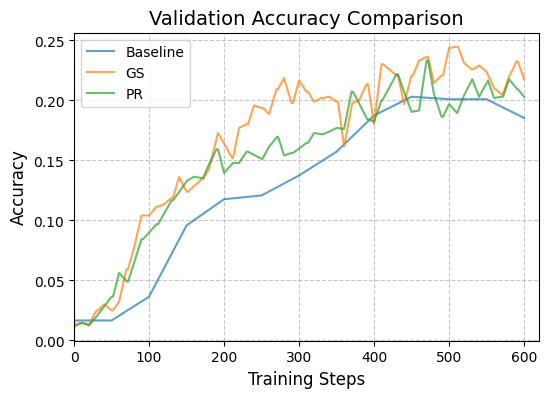

In [ ]:
# Get the data and remove NaN values
data_baseline = history_baseline['val/math_dapo/acc/mean@32'].dropna()
data_gs = history_gs['val/math_dapo/acc/mean@32'].dropna()
data_gs_2 = history_gs_2['val/math_dapo/acc/mean@32'].dropna()
data_pr = history_pr['val/math_dapo/acc/mean@32'].dropna()
data_pr_2 = history_pr_2['val/math_dapo/acc/mean@32'].dropna()




# Create x-axis values (scaled by 5x for baseline). Use _step as x-axis
# Extract step values for x-axis
x_values_baseline = history_baseline['_step'].values[data_baseline.index]
x_values_gs = history_gs['_step'].values[data_gs.index]
x_values_pr = history_pr['_step'].values[data_pr.index]

# Scale baseline by 5x as instructed
x_values_baseline = x_values_baseline * 5


# Cutoff data at x=400
max_x = 600
# Create boolean masks to ensure correspondence is maintained
mask_baseline = x_values_baseline <= max_x
data_baseline = data_baseline[mask_baseline]
x_values_baseline = x_values_baseline[mask_baseline]

mask_gs = x_values_gs <= max_x
data_gs = data_gs[mask_gs]
x_values_gs = x_values_gs[mask_gs]

mask_pr = x_values_pr <= max_x
data_pr = data_pr[mask_pr]
x_values_pr = x_values_pr[mask_pr]

# Create the plot
plt.figure(figsize=(6, 4))
# Set global font size for better readability
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})


# Plot each dataset with appropriate labels
plt.plot(x_values_baseline, data_baseline, label='Baseline', linestyle='-', alpha=0.7)
plt.plot(x_values_gs, data_gs, label='GS', linestyle='-', alpha=0.7)
plt.plot(x_values_pr, data_pr, label='PR', linestyle='-', alpha=0.7)

# Add labels and title
plt.xlabel('Training Steps')
plt.ylabel('Accuracy')
plt.xlim(0, 620)
plt.title('Validation Accuracy Comparison')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()



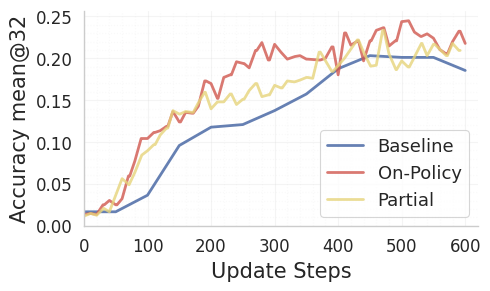

In [83]:
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("paper")

# Prepare data for seaborn (need to create a long-form dataframe)
import pandas as pd

# Get the data and remove NaN values (same as before)
data_baseline = history_baseline['val/math_dapo/acc/mean@32'].dropna()
data_gs = history_gs['val/math_dapo/acc/mean@32'].dropna()
data_pr = history_pr['val/math_dapo/acc/mean@32'].dropna()

# Extract step values for x-axis
x_values_baseline = history_baseline['_step'].values[data_baseline.index]
x_values_gs = history_gs['_step'].values[data_gs.index]
x_values_pr = history_pr['_step'].values[data_pr.index]

# Scale baseline by 5x as instructed
x_values_baseline = x_values_baseline * 5

# Cutoff data at x=600
max_x = 600
mask_baseline = x_values_baseline <= max_x
data_baseline = data_baseline[mask_baseline]
x_values_baseline = x_values_baseline[mask_baseline]

mask_gs = x_values_gs <= max_x
data_gs = data_gs[mask_gs]
x_values_gs = x_values_gs[mask_gs]

mask_pr = x_values_pr <= max_x
data_pr = data_pr[mask_pr]
x_values_pr = x_values_pr[mask_pr]

# Create dataframes for each model
df_baseline = pd.DataFrame({
    'Training Steps': x_values_baseline,
    'Accuracy': data_baseline.values,
    'Model': 'Baseline'
})

df_gs = pd.DataFrame({
    'Training Steps': x_values_gs,
    'Accuracy': data_gs.values,
    'Model': 'On-Policy'
})

df_pr = pd.DataFrame({
    'Training Steps': x_values_pr,
    'Accuracy': data_pr.values,
    'Model': 'Partial'
})

# Combine all dataframes
df_combined = pd.concat([df_baseline, df_gs, df_pr], ignore_index=True)

# Create the plot
plt.figure(figsize=(5, 3))

# Use seaborn lineplot
ax = sns.lineplot(data=df_combined, 
                  x='Training Steps', 
                  y='Accuracy', 
                  hue='Model',
                  linewidth=2,
                  alpha=0.8,
                  palette=['#4061A0', '#D0574E', '#E6D47B'])

# Customize the plot
plt.xlim(0, 620)
# Title removed
plt.xlabel('Update Steps', fontsize=15)
plt.ylabel('Accuracy mean@32', fontsize=15)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Customize legend
plt.legend(fontsize=13, frameon=True, loc='lower right')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add minor gridlines for better readability
ax.grid(True, which='major', linestyle='-', alpha=0.2)
ax.grid(True, which='minor', linestyle=':', alpha=0.1)
ax.minorticks_on()

# Tight layout for better appearance
plt.tight_layout()

fig = plt.gcf()
fig.savefig('aime_dapo.pdf')

plt.show()


In [93]:
print(history_baseline[history_baseline['_step']==150]['val/math_dapo/acc/mean@32'])
print(history_gs[history_gs['_step']==600]['val/math_dapo/acc/mean@32'])
print(history_pr[history_pr['_step']==600]['val/math_dapo/acc/mean@32'])


150    0.216667
Name: val/math_dapo/acc/mean@32, dtype: float64
520    0.217708
Name: val/math_dapo/acc/mean@32, dtype: float64
460    0.203125
Name: val/math_dapo/acc/mean@32, dtype: float64


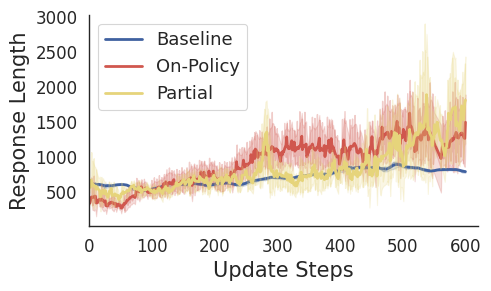

In [78]:
import seaborn as sns
import numpy as np
from scipy.ndimage import uniform_filter1d

# Set seaborn style
sns.set_style("white")
sns.set_context("paper")

# Prepare data for seaborn (need to create a long-form dataframe)
import pandas as pd

# Get the data and remove NaN values (same as before)
data_baseline = history_baseline['response_length/mean'].dropna()
data_gs = history_gs['response_length/mean'].dropna()
data_pr = history_pr['response_length/mean'].dropna()

# Extract step values for x-axis
x_values_baseline = history_baseline['_step'].values[data_baseline.index]
x_values_gs = history_gs['_step'].values[data_gs.index]
x_values_pr = history_pr['_step'].values[data_pr.index]

# Scale baseline by 5x as instructed
x_values_baseline = x_values_baseline * 5

# Cutoff data at x=600
max_x = 600
mask_baseline = x_values_baseline <= max_x
data_baseline = data_baseline[mask_baseline]
x_values_baseline = x_values_baseline[mask_baseline]

mask_gs = x_values_gs <= max_x
data_gs = data_gs[mask_gs]
x_values_gs = x_values_gs[mask_gs]

mask_pr = x_values_pr <= max_x
data_pr = data_pr[mask_pr]
x_values_pr = x_values_pr[mask_pr]

# Function to compute moving average and range
def compute_ma_and_range(x_values, y_values, window=4):
    # Compute moving average
    ma = uniform_filter1d(y_values, size=window)
    
    # Compute rolling standard deviation
    rolling_std = pd.Series(y_values).rolling(window=window).std().fillna(0).values
    
    # Create upper and lower bounds
    upper = ma + rolling_std
    lower = ma - rolling_std
    
    return ma, upper, lower

# Create the plot
plt.figure(figsize=(5, 3))

# Plot for each model with moving average and range
colors = ['#4061A0', '#D0574E', '#E6D47B']
labels = ['Baseline', 'On-Policy', 'Partial']
data_sets = [(x_values_baseline, data_baseline),
             (x_values_gs, data_gs),
             (x_values_pr, data_pr)]

for (x_values, data), color, label in zip(data_sets, colors, labels):
    # Compute moving average and range
    ma, upper, lower = compute_ma_and_range(x_values, data)
    
    # Plot original data with low alpha
    plt.plot(x_values, data, color=color, alpha=0.3, linewidth=1)
    
    # Plot moving average
    plt.plot(x_values, ma, color=color, label=label, linewidth=2)
    
    # Plot range as shadow
    plt.fill_between(x_values, lower, upper, color=color, alpha=0.2)

# Customize the plot
plt.xlim(0, 620)
plt.xlabel('Update Steps', fontsize=15)
plt.ylabel('Response Length', fontsize=15)  # Changed from 'Accuracy' to 'Response Length'

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Customize legend
plt.legend(fontsize=13, frameon=True, loc='upper left')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add minor gridlines for better readability
# plt.grid(True, which='major', linestyle='-', alpha=0.2)
# plt.grid(True, which='minor', linestyle=':', alpha=0.1)
# plt.gca().minorticks_on()

# Tight layout for better appearance
plt.tight_layout()
fig = plt.gcf()
fig.savefig('response_length_dapo.pdf', bbox_inches='tight')

plt.show()


## KK

In [79]:
run_baseline = api.run("viatage/LogicRL-RPP/runs/9fb06ac6-f0c0-4f54-909d-1f3843b9d5ad")
run_gs = api.run("viatage/LogicRL-RPP/runs/00ccc636-d7e4-449c-83b3-bb6bd6a6494b")
run_pr = api.run("viatage/LogicRL-RPP-R/a86cc051-b62c-418b-8e8e-cd1e6c300c55")
history_baseline = run_baseline.history()
history_gs = run_gs.history()
history_pr = run_pr.history()

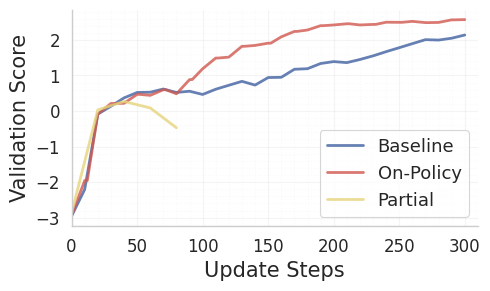

In [80]:
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("paper")

# Prepare data for seaborn (need to create a long-form dataframe)
import pandas as pd

# Get the data and remove NaN values (same as before)
data_baseline = history_baseline['val/test_score/kk_logic'].dropna()
data_gs = history_gs['val/test_score/kk_logic'].dropna()
data_pr = history_pr['val/test_score/kk_logic'].dropna()

# Extract step values for x-axis
x_values_baseline = history_baseline['_step'].values[data_baseline.index]
x_values_gs = history_gs['_step'].values[data_gs.index]
x_values_pr = history_pr['_step'].values[data_pr.index]

# Cutoff data at x=600
max_x = 300
mask_baseline = x_values_baseline <= max_x
data_baseline = data_baseline[mask_baseline]
x_values_baseline = x_values_baseline[mask_baseline]

mask_gs = x_values_gs <= max_x
data_gs = data_gs[mask_gs]
x_values_gs = x_values_gs[mask_gs]

mask_pr = x_values_pr <= max_x
data_pr = data_pr[mask_pr]
x_values_pr = x_values_pr[mask_pr]

# Create dataframes for each model
df_baseline = pd.DataFrame({
    'Training Steps': x_values_baseline,
    'Accuracy': data_baseline.values,
    'Model': 'Baseline'
})

df_gs = pd.DataFrame({
    'Training Steps': x_values_gs,
    'Accuracy': data_gs.values,
    'Model': 'On-Policy'
})

df_pr = pd.DataFrame({
    'Training Steps': x_values_pr,
    'Accuracy': data_pr.values,
    'Model': 'Partial'
})

# Combine all dataframes
df_combined = pd.concat([df_baseline, df_gs, df_pr], ignore_index=True)

# Create the plot
plt.figure(figsize=(5, 3))

# Use seaborn lineplot
ax = sns.lineplot(data=df_combined, 
                  x='Training Steps', 
                  y='Accuracy', 
                  hue='Model',
                  linewidth=2,
                  alpha=0.8,
                  palette=['#4061A0', '#D0574E', '#E6D47B'])

# Customize the plot
plt.xlim(0, 310)
# Title removed
plt.xlabel('Update Steps', fontsize=15)
plt.ylabel('Validation Score', fontsize=15)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Customize legend
plt.legend(fontsize=13, frameon=True, loc='lower right')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add minor gridlines for better readability
ax.grid(True, which='major', linestyle='-', alpha=0.2)
ax.grid(True, which='minor', linestyle=':', alpha=0.1)
ax.minorticks_on()

# Tight layout for better appearance
plt.tight_layout()

fig = plt.gcf()
fig.savefig('val_kk.pdf')

plt.show()


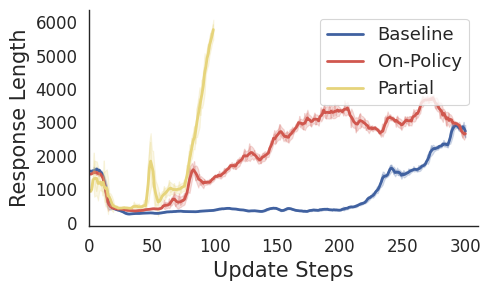

In [81]:
import seaborn as sns
import numpy as np
from scipy.ndimage import uniform_filter1d

# Set seaborn style
sns.set_style("white")
sns.set_context("paper")

# Prepare data for seaborn (need to create a long-form dataframe)
import pandas as pd

# Get the data and remove NaN values (same as before)
data_baseline = history_baseline['response_length/mean'].dropna()
data_gs = history_gs['response_length/mean'].dropna()
data_pr = history_pr['response_length/mean'].dropna()

# Extract step values for x-axis
x_values_baseline = history_baseline['_step'].values[data_baseline.index]
x_values_gs = history_gs['_step'].values[data_gs.index]
x_values_pr = history_pr['_step'].values[data_pr.index]

# Scale baseline by 5x as instructed
# x_values_baseline = x_values_baseline * 5

# Cutoff data at x=600
max_x = 300
mask_baseline = x_values_baseline <= max_x
data_baseline = data_baseline[mask_baseline]
x_values_baseline = x_values_baseline[mask_baseline]

mask_gs = x_values_gs <= max_x
data_gs = data_gs[mask_gs]
x_values_gs = x_values_gs[mask_gs]

mask_pr = x_values_pr <= max_x
data_pr = data_pr[mask_pr]
x_values_pr = x_values_pr[mask_pr]

# Function to compute moving average and range
def compute_ma_and_range(x_values, y_values, window=4):
    # Compute moving average
    ma = uniform_filter1d(y_values, size=window)
    
    # Compute rolling standard deviation
    rolling_std = pd.Series(y_values).rolling(window=window).std().fillna(0).values
    
    # Create upper and lower bounds
    upper = ma + rolling_std
    lower = ma - rolling_std
    
    return ma, upper, lower

# Create the plot
plt.figure(figsize=(5, 3))

# Plot for each model with moving average and range
colors = ['#4061A0', '#D0574E', '#E6D47B']
labels = ['Baseline', 'On-Policy', 'Partial']
data_sets = [(x_values_baseline, data_baseline),
             (x_values_gs, data_gs),
             (x_values_pr, data_pr)]

for (x_values, data), color, label in zip(data_sets, colors, labels):
    # Compute moving average and range
    ma, upper, lower = compute_ma_and_range(x_values, data)
    
    # Plot original data with low alpha
    plt.plot(x_values, data, color=color, alpha=0.3, linewidth=1)
    
    # Plot moving average
    plt.plot(x_values, ma, color=color, label=label, linewidth=2)
    
    # Plot range as shadow
    plt.fill_between(x_values, lower, upper, color=color, alpha=0.2)

# Customize the plot
plt.xlim(0, 310)
plt.xlabel('Update Steps', fontsize=15)
plt.ylabel('Response Length', fontsize=15)  # Changed from 'Accuracy' to 'Response Length'

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Customize legend
plt.legend(fontsize=13, frameon=True, loc='upper right')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add minor gridlines for better readability
# plt.grid(True, which='major', linestyle='-', alpha=0.2)
# plt.grid(True, which='minor', linestyle=':', alpha=0.1)
# plt.gca().minorticks_on()

# Tight layout for better appearance
plt.tight_layout()
fig = plt.gcf()
fig.savefig('response_length_kk.pdf', bbox_inches='tight')

plt.show()
